# HCIA-AI Study Assistant: Indexing & RAG Pipeline

This notebook **builds everything the app needs**:

| Part | What it does | Output |
|---|---|---|
| 1. EDA | Checks text extraction and duplicates in the lecture PDFs | Decisions table + chart |
| 2. Question bank | Converts the Word question bank to structured data | `question_bank.json` |
| 3. Pages → chunks | One slide = one chunk, cleaned, empty + duplicate pages removed | `pages.json` |
| 4. Index | Dense embeddings + ChromaDB with metadata (lecture, page) | `rag_db/` |
| 5. Retrieval | Hybrid search (dense + TF-IDF) | test results |
| 6. Generation | Grounded explanation with slide citations | test answers |

The app (`app.py`) only **reads** `rag_db/` and `question_bank.json`.

**Project folder layout**
```
RAG-Project/
├── Study_Assistant_Pipeline.ipynb
├── app.py
├── .env                    ← OPENAI_API_KEY=...
├── question_bank.docx
├── lectures/               ← PDFs we index
└── excluded/               ← PDFs we checked and decided NOT to index
```

## 0. Setup

In [12]:
# Run once if a library is missing
# %pip install pypdf python-docx langchain-openai python-dotenv sentence-transformers chromadb scikit-learn pandas matplotlib streamlit

In [13]:
import os
import re
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chromadb
from docx import Document
from dotenv import load_dotenv
from pypdf import PdfReader
from langchain_openai import ChatOpenAI
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

In [14]:
# ---------- Paths (relative → works on any computer after git clone) ----------
BASE_DIR = Path.cwd()          # the folder this notebook is in

LECTURES_DIR = BASE_DIR / "lectures"
EXCLUDED_DIR = BASE_DIR / "excluded"
BANK_DOCX    = BASE_DIR / "question_bank.docx"
BANK_JSON    = BASE_DIR / "question_bank.json"
PAGES_JSON   = BASE_DIR / "pages.json"
DB_PATH      = BASE_DIR / "rag_db"
ENV_PATH     = BASE_DIR / ".env"

# ---------- Settings (must match app.py) ----------
COLLECTION_NAME = "lectures"
MODEL_NAME      = "BAAI/bge-small-en-v1.5"
LLM_NAME        = "gpt-4o-mini"
MIN_CHARS       = 30           # pages shorter than this are treated as empty

# ---------- API key ----------
load_dotenv(ENV_PATH, override=True)
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError(f"OPENAI_API_KEY not found in {ENV_PATH}")

for name, path in [("lectures/", LECTURES_DIR), ("excluded/", EXCLUDED_DIR),
                   ("question bank", BANK_DOCX), (".env", ENV_PATH)]:
    print(f"{name:14} exists: {path.exists()}")

print("\nPDFs to index:", len(list(LECTURES_DIR.glob("*.pdf"))))
print("PDFs excluded:", len(list(EXCLUDED_DIR.glob("*.pdf"))))

lectures/      exists: True
excluded/      exists: True
question bank  exists: True
.env           exists: True

PDFs to index: 19
PDFs excluded: 5


## 1. EDA: can we read the lectures?

Before indexing, we check that `pypdf` actually extracts text from every file.
A slide that is an image returns empty text, and the model would silently know nothing about it.

We check **both** folders, so the table also documents *why* the excluded files were excluded.

In [15]:
def get_pages_text(pdf_path):
    reader = PdfReader(pdf_path)
    pages_text = []
    for page in reader.pages:
        text = page.extract_text() or ""
        pages_text.append(text.strip())
    return pages_text


all_pdfs = []
for pdf_path in sorted(LECTURES_DIR.glob("*.pdf")):
    all_pdfs.append((pdf_path, "indexed"))
for pdf_path in sorted(EXCLUDED_DIR.glob("*.pdf")):
    all_pdfs.append((pdf_path, "excluded"))

rows = []
for pdf_path, status in all_pdfs:
    pages_text = get_pages_text(pdf_path)
    lengths = [len(t) for t in pages_text]
    empty_count = sum(1 for n in lengths if n < MIN_CHARS)

    rows.append({
        "file": pdf_path.stem,
        "status": status,
        "pages": len(pages_text),
        "avg_chars": round(sum(lengths) / len(lengths)),
        "empty_pages": empty_count,
        "empty_%": round(empty_count / len(pages_text) * 100),
    })

eda_df = pd.DataFrame(rows).sort_values("empty_%", ascending=False)
eda_df

,file,status,pages,avg_chars,empty_pages,empty_%
22,Linear_Regression-1 2,excluded,79,0,79,100
3,decision tree & ensemble learning & random forest,indexed,55,245,22,40
23,NLP - Text preprocessing,excluded,64,254,25,39
20,Hierarchical Clustering,excluded,27,94,8,30
4,decision tree & ensemble learning,indexed,107,294,29,27
21,K-means,excluded,37,142,8,22
18,Word Embedding,indexed,36,496,7,19
12,Imbalanced_Data,indexed,19,476,1,5
7,Feature Selection in Machine Learning,indexed,37,642,0,0
6,Exploratory Data Analysis_Nancy Ahmed (2),indexed,45,382,0,0


**Chart:** percentage of pages with no extractable text, per file.
- **X-axis:** % of empty pages
- **Y-axis:** file name
- **Look for:** long bars = content we cannot read as text (images / screenshots).
- **Careful:** an empty page is not always lost content. It can be a title slide or a diagram.
  We opened the flagged files to check (see the decisions table below).

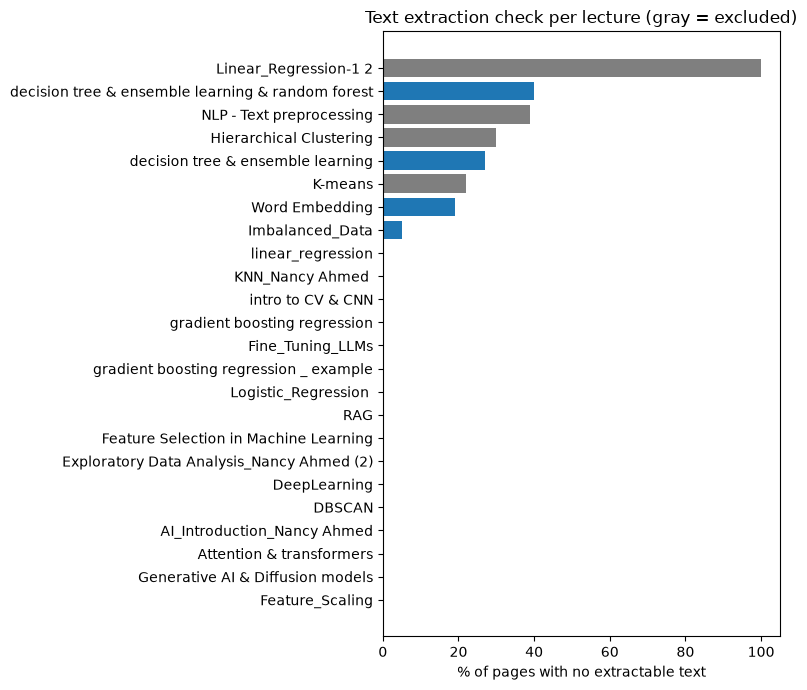

In [16]:
plot_df = eda_df.sort_values("empty_%")
colors = ["tab:gray" if s == "excluded" else "tab:blue" for s in plot_df["status"]]

plt.figure(figsize=(8, 7))
plt.barh(plot_df["file"], plot_df["empty_%"], color=colors)
plt.xlabel("% of pages with no extractable text")
plt.title("Text extraction check per lecture (gray = excluded)")
plt.tight_layout()
plt.show()

### Duplicate check
Two files had the same page count and average length, and two others shared the same empty-page pattern.
Duplicates hurt RAG: with `top_k=3`, two of the three results could be the same slide, and the quiz would repeat questions.

In [17]:
a = get_pages_text(LECTURES_DIR / "gradient boosting regression.pdf")
b = get_pages_text(EXCLUDED_DIR / "gradient boosting regression _ example.pdf")
print("Gradient boosting files identical:", a == b)

small = get_pages_text(LECTURES_DIR / "decision tree & ensemble learning & random forest.pdf")
big = get_pages_text(LECTURES_DIR / "decision tree & ensemble learning.pdf")

big_set = set(big)
non_empty_small = [page for page in small if page]
found = 0
for page in non_empty_small:
    if page in big_set:
        found += 1

print(f"{found} / {len(non_empty_small)} pages of the small decision tree file exist in the big file")

Gradient boosting files identical: True
32 / 43 pages of the small decision tree file exist in the big file


### Decisions from the EDA

| Finding | Decision | Why |
|---|---|---|
| `gradient boosting regression _ example` is 100% identical to `gradient boosting regression` | Moved to `excluded/` | Exact duplicate |
| `Linear_Regression-1 2` has 0 extractable characters (79 pages) | Moved to `excluded/` | Opened it: 60+ pages are graphs used for visual explanation, no real text content. The text version is `linear_regression` |
| Small decision tree file: 32 / 43 pages exist in the big file | Keep **both**, remove duplicate **pages** automatically (Section 3) | The small file has 11 unique pages |
| Hierarchical Clustering, K-means, NLP, Word Embedding have many empty pages | Index the text now; screenshots are a **known limitation** | Opened Hierarchical: most empty pages are screenshots with text inside. Possible fix later: a vision LLM to transcribe them |
| All other files | Index normally | Text extracts correctly |

## 2. Question bank → structured data

The bank is a Word file: section headings (style `Heading 1`), then questions like
`2. [Multiple-Choice — select all that apply] Which ...`, each followed by options `A.` to `D.`.

We convert it to a list of dicts so the app can filter by section and show options as buttons.

**Important:** the bank has **no answers**. We use it for:
1. **Style examples (few-shot)** when generating new quiz questions from the lectures
2. **Practice mode**, where our RAG answers the bank question from the lectures and shows the source slide

In [18]:
doc = Document(BANK_DOCX)

questions = []
current_section = None
current_question = None

for paragraph in doc.paragraphs:
    text = paragraph.text.strip()
    if not text:
        continue

    # 1) Section title, e.g. "1. AI Fundamentals & Applications"
    if paragraph.style.name == "Heading 1":
        current_section = re.sub(r"^\d+\.\s*", "", text)
        continue

    # 2) Question line, e.g. "2. [Multiple-Choice — select all that apply] Which of..."
    question_match = re.match(r"^(\d+)\.\s*\[(.+?)\]\s*(.+)$", text)
    if question_match:
        number = int(question_match.group(1))
        type_text = question_match.group(2)
        question_text = question_match.group(3)

        if type_text.startswith("Multiple"):
            q_type = "multiple"
        else:
            q_type = "single"

        current_question = {
            "id": f"bank_{number}",
            "section": current_section,
            "type": q_type,
            "question": question_text,
            "options": {}
        }
        questions.append(current_question)
        continue

    # 3) Option line, e.g. "A. Predictive maintenance of equipment"
    option_match = re.match(r"^([A-F])\.\s*(.+)$", text)
    if option_match and current_question is not None:
        letter = option_match.group(1)
        current_question["options"][letter] = option_match.group(2)


# ---------- Sanity checks (expected: 130 questions, 100 single / 30 multiple, all with 4 options) ----------
print("Total questions:", len(questions))
print("Per type:", Counter(q["type"] for q in questions))
print("Options per question:", Counter(len(q["options"]) for q in questions))
print("\nPer section:")
for section, count in Counter(q["section"] for q in questions).items():
    print(f"  {count:3}  {section}")

with open(BANK_JSON, "w", encoding="utf-8") as f:
    json.dump(questions, f, ensure_ascii=False, indent=2)
print("\nSaved →", BANK_JSON.name)

Total questions: 130
Per type: Counter({'single': 100, 'multiple': 30})
Options per question: Counter({4: 130})

Per section:
   13  AI Fundamentals & Applications
   12  Machine Learning Basics
   15  Neural Networks & Activation Functions
   13  Training, Optimization & Regularization
   12  CNNs & Computer Vision
   12  NLP, Transformer & Attention
   14  Frameworks & Tools
   15  Large Models & Fine-Tuning
   12  Parallel Training
   12  Data Preprocessing & Evaluation

Saved → question_bank.json


## 3. Pages → chunks (page-based chunking)

**Decision: one slide = one chunk.**

| | Agentic chunking (first experiment, see Appendix) | Page-based (chosen) |
|---|---|---|
| Idea | LLM decides which paragraphs belong together | Each slide is one chunk |
| Page number for citations | Lost (pages were joined before splitting) | Kept automatically |
| Cost / time for 22 PDFs | One API call per paragraph | Zero |
| Fits our data? | Better for long continuous text | Slides already hold ~one idea each |

For every page we:
1. **Clean** it (`fix_spaced_letters`: `Q U A N T I Z E D` → `QUANTIZED`)
2. **Skip** it if it is empty (< `MIN_CHARS`)
3. **Skip** it if the exact same text was already added (duplicate pages across files)
4. **Keep** its metadata: lecture name + page number

In [19]:
def fix_spaced_letters(text):
    # 3+ single characters separated by single spaces → join them
    pattern = r'\b(?:[A-Za-z0-9&\-] ){2,}[A-Za-z0-9&\-]\b'
    text = re.sub(pattern, lambda m: m.group(0).replace(" ", ""), text)

    # collapse repeated spaces (keep newlines)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()


def clean_lecture_name(file_stem):
    # "KNN_Nancy Ahmed " → "KNN" ,  "Exploratory Data Analysis_Nancy Ahmed (2)" → "Exploratory Data Analysis"
    name = file_stem.replace("_Nancy Ahmed", "")
    name = name.replace("(2)", "")
    name = name.replace("_", " ")
    name = re.sub(r"\s+", " ", name)
    return name.strip()


print(clean_lecture_name("KNN_Nancy Ahmed "))
print(clean_lecture_name("Exploratory Data Analysis_Nancy Ahmed (2)"))

KNN
Exploratory Data Analysis


In [20]:
pages = []            # the chunks we will index
seen_texts = set()    # cleaned text of every page already added → catches duplicates
report_rows = []      # what happened to each file

for pdf_path in sorted(LECTURES_DIR.glob("*.pdf")):
    lecture = clean_lecture_name(pdf_path.stem)
    pages_text = get_pages_text(pdf_path)

    kept = 0
    skipped_empty = 0
    skipped_duplicate = 0

    for page_number, raw_text in enumerate(pages_text, start=1):
        text = fix_spaced_letters(raw_text)

        if len(text) < MIN_CHARS:
            skipped_empty += 1
            continue

        if text in seen_texts:
            skipped_duplicate += 1
            continue

        seen_texts.add(text)
        pages.append({
            "id": f"{lecture}_p{page_number}",
            "lecture": lecture,
            "page": page_number,
            "source": pdf_path.name,
            "text": text,
        })
        kept += 1

    report_rows.append({
        "lecture": lecture,
        "pages": len(pages_text),
        "kept": kept,
        "skipped_empty": skipped_empty,
        "skipped_duplicate": skipped_duplicate,
    })

report_df = pd.DataFrame(report_rows)
print("Total chunks:", len(pages))
print("Unique ids:", len(set(p["id"] for p in pages)) == len(pages))
report_df

Total chunks: 802
Unique ids: True


,lecture,pages,kept,skipped_empty,skipped_duplicate
0,AI Introduction,45,45,0,0
1,Attention & transformers,47,47,0,0
2,DBSCAN,14,14,0,0
3,decision tree & ensemble learning & random forest,55,33,22,0
4,decision tree & ensemble learning,107,56,29,22
5,DeepLearning,87,87,0,0
6,Exploratory Data Analysis,45,43,0,2
7,Feature Selection in Machine Learning,37,37,0,0
8,Feature Scaling,17,17,0,0
9,Fine Tuning LLMs,58,58,0,0


**What to expect:** most files have `skipped_duplicate = 0`.
The small decision tree file (it comes first alphabetically, so it is added first) keeps all its pages,
and the **big** one should show ~32 skipped duplicates.

In [21]:
with open(PAGES_JSON, "w", encoding="utf-8") as f:
    json.dump(pages, f, ensure_ascii=False, indent=2)
print("Saved →", PAGES_JSON.name)

print("\nExample chunk:")
print(pages[10]["id"])
print(pages[10]["text"][:300])

Saved → pages.json

Example chunk:
AI Introduction_p11
11 Copyright @ 2026 NTI 
THE ONLY TYPE THAT EXISTS TODAY
AI designed to 
perform one specific 
task very well.
Even ChatGPT — despite 
doing many language tasks —
is still Narrow AI: it is 
specialized and lacks human-
level general intelligence 
across all domains.
EXAMPLES
ChatGPT Siri Face 
Recog


## 4. Embeddings + ChromaDB

`bge-small-en-v1.5`: max 512 tokens, 384 dimensions, English only.

**Lecture name inside the embedded text:** many slides never mention their topic
(e.g. *"Step 2: assign each point to the nearest centroid"* never says "K-means").
So we embed `"[K-means]\n" + text`. This way a question about K-means can still find that slide,
for both dense and TF-IDF search.

In [22]:
dense_model = SentenceTransformer(MODEL_NAME)
print("Max tokens:", dense_model.max_seq_length)
print("Embedding dim:", dense_model.get_embedding_dimension())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2842.87it/s]


Max tokens: 512
Embedding dim: 384


In [23]:
documents = []
for p in pages:
    documents.append(f"[{p['lecture']}]\n{p['text']}")

# Check how many chunks exceed the model limit (-2 for [CLS] and [SEP])
token_counts = [len(dense_model.tokenizer.tokenize(d)) for d in documents]
limit = dense_model.max_seq_length - 2
too_long = [pages[i]["id"] for i, n in enumerate(token_counts) if n > limit]

print("Largest chunk (tokens):", max(token_counts))
print("Average chunk (tokens):", round(sum(token_counts) / len(token_counts)))
print("Chunks that will be truncated:", len(too_long), too_long[:10])

Largest chunk (tokens): 370
Average chunk (tokens): 99
Chunks that will be truncated: 0 []


In [24]:
dense_vectors = dense_model.encode(
    documents,
    normalize_embeddings=True,
    show_progress_bar=True
)
print("Dense shape:", dense_vectors.shape)

Batches: 100%|██████████| 26/26 [00:51<00:00,  1.97s/it]

Dense shape: (802, 384)


In [25]:
client = chromadb.PersistentClient(path=str(DB_PATH))

try:
    client.delete_collection(COLLECTION_NAME)
except Exception:
    pass

collection = client.create_collection(
    name=COLLECTION_NAME,
    embedding_function=None,
    metadata={"hnsw:space": "cosine"}
)

chunk_ids = []
chunk_metadatas = []
for p in pages:
    chunk_ids.append(p["id"])
    chunk_metadatas.append({
        "lecture": p["lecture"],
        "page": p["page"],
        "source": p["source"],
    })

collection.add(
    ids=chunk_ids,
    documents=documents,
    embeddings=dense_vectors.tolist(),
    metadatas=chunk_metadatas
)
print("Chunks stored:", collection.count())

Chunks stored: 802


In [26]:
# Metadata filter test: this is how the quiz will get the slides of ONE lecture
knn_slides = collection.get(where={"lecture": "KNN"}, include=["metadatas"])
print("KNN slides in the DB:", len(knn_slides["ids"]))
print(knn_slides["ids"][:5])

KNN slides in the DB: 64
['KNN_p2', 'KNN_p3', 'KNN_p4', 'KNN_p5', 'KNN_p6']


## 5. Load from ChromaDB + Hybrid Search
This is exactly what `app.py` does when it starts.
TF-IDF is **fit on the stored chunks only**, and the query is only **transformed** (no fit), same as train/test.

In [27]:
client = chromadb.PersistentClient(path=str(DB_PATH))
collection = client.get_collection(name=COLLECTION_NAME, embedding_function=None)

stored = collection.get(include=["documents", "metadatas"])
stored_ids = stored["ids"]
stored_docs = stored["documents"]
stored_metas = stored["metadatas"]
print("Loaded chunks:", len(stored_docs))

tfidf = TfidfVectorizer(lowercase=True, stop_words="english")
sparse_vectors = tfidf.fit_transform(stored_docs)
print("Sparse shape:", sparse_vectors.shape)

Loaded chunks: 802
Sparse shape: (802, 4732)


In [28]:
def embed_query(query):
    query = query.strip()
    if not query:
        raise ValueError("Query is empty!")

    # Dense: same model + same normalization as the chunks
    query_dense = dense_model.encode([query], normalize_embeddings=True)

    # Sparse: same TF-IDF, transform only (no fit!)
    query_sparse = tfidf.transform([query])

    return query_dense, query_sparse


def min_max(scores):
    if scores.max() == scores.min():
        return np.zeros_like(scores)
    return (scores - scores.min()) / (scores.max() - scores.min())


def hybrid_search(query, alpha=0.5, top_k=3):
    query_dense, query_sparse = embed_query(query)

    # 1) Dense scores from ChromaDB (cosine distance → similarity)
    results = collection.query(
        query_embeddings=query_dense.tolist(),
        n_results=collection.count(),
        include=["distances"]
    )
    dense_by_id = {}
    for chunk_id, distance in zip(results["ids"][0], results["distances"][0]):
        dense_by_id[chunk_id] = 1 - distance
    dense_scores = np.array([dense_by_id[chunk_id] for chunk_id in stored_ids])

    # 2) Sparse scores from TF-IDF
    sparse_scores = (sparse_vectors @ query_sparse.T).toarray().ravel()

    # 3) Normalize + combine
    hybrid_scores = alpha * min_max(dense_scores) + (1 - alpha) * min_max(sparse_scores)

    # 4) Top results
    top_positions = np.argsort(hybrid_scores)[::-1][:top_k]

    top_chunks = []
    for pos in top_positions:
        top_chunks.append({
            "id": stored_ids[pos],
            "lecture": stored_metas[pos]["lecture"],
            "page": stored_metas[pos]["page"],
            "text": stored_docs[pos],
            "score": hybrid_scores[pos],
        })
    return top_chunks

In [29]:
test_queries = [
    "What is QLoRA?",
    "How does K-means choose the centroids?",
    "What is the difference between bagging and boosting?",
    "Why do we scale features before KNN?",
]

for query in test_queries:
    print("Q:", query)
    for r in hybrid_search(query, alpha=0.5, top_k=3):
        print(f"   {r['score']:.2f} | {r['lecture']} p.{r['page']}")
    print()

Q: What is QLoRA?
   1.00 | Fine Tuning LLMs p.15
   0.75 | Fine Tuning LLMs p.17
   0.56 | Fine Tuning LLMs p.23

Q: How does K-means choose the centroids?
   0.94 | DBSCAN p.2
   0.81 | KNN p.27
   0.71 | KNN p.11

Q: What is the difference between bagging and boosting?
   0.91 | decision tree & ensemble learning p.106
   0.89 | decision tree & ensemble learning & random forest p.29
   0.89 | decision tree & ensemble learning p.107

Q: Why do we scale features before KNN?
   0.89 | KNN p.53
   0.87 | Feature Scaling p.15
   0.84 | KNN p.64



**What to look for:** the top result should come from the lecture you expect.
If a question goes to the wrong lecture, note it: these are exactly the cases the evaluation (Hit@3 for different alpha values) will measure.

## 6. Generation (Explain mode)
The LLM explains **only** from the retrieved slides (grounding) and cites them as `[Lecture p.X]`.

In [30]:
gen_llm = ChatOpenAI(model=LLM_NAME, temperature=0)

In [31]:
def build_prompt(query, retrieved_chunks):
    context_parts = []
    for c in retrieved_chunks:
        context_parts.append(f"[{c['lecture']} p.{c['page']}]\n{c['text']}")
    context = "\n\n---\n\n".join(context_parts)

    return f"""You are a helpful tutor helping a student study an AI / Machine Learning course.
The context below contains the lecture slides most relevant to the question.

How to answer:
1. Find every sentence in the context related to the question, even if it uses different words.
2. Explain clearly using only those sentences. Do not add outside knowledge.
3. If the slides cover the question only partly, explain what they cover,
   then add one line saying what they do not cover.
4. Reply "I don't know based on the lectures." ONLY if nothing in the context is related.
5. Cite the slides you used, like [K-means p.12].

Context:
{context}

Question: {query}

Answer:"""


def rag_answer(query, alpha=0.5, top_k=3):
    retrieved = hybrid_search(query, alpha=alpha, top_k=top_k)

    print("Retrieved:")
    for r in retrieved:
        print(f"   {r['score']:.2f} | {r['lecture']} p.{r['page']}")

    prompt = build_prompt(query, retrieved)
    response = gen_llm.invoke(prompt)
    return response.content, retrieved

In [32]:
answer, used_chunks = rag_answer("How does K-means choose the centroids?")
print("\n" + answer)

print("\n" + "=" * 60 + "\n")

answer, used_chunks = rag_answer("Who won the 2022 World Cup?")
print("\n" + answer)

Retrieved:
   0.94 | DBSCAN p.2
   0.81 | KNN p.27
   0.71 | KNN p.11


OpenAIAuthenticationError: Error code: 401 - {'error': {'message': 'Your API key has expired. Create a new API key to continue.', 'type': 'invalid_request_error', 'code': 'expired_secret_key', 'param': None}, 'status': 401}

`rag_answer` now also returns `retrieved`: these are the slides of "the part you asked about".
In the app they are saved in `st.session_state`, and the **Quiz me on this** button generates questions from them (next step).

---
## 7. Next steps
- [ ] Quiz generation from `used_chunks` (JSON output, single + multiple choice, few-shot from the bank)
- [ ] Update `app.py`
- [ ] Evaluation: Hit@3 for alpha = 0 / 0.5 / 1
- [ ] (Optional) Vision LLM for screenshot pages · bank coverage chart per section

---
## Appendix: first experiment, Agentic chunking (not used)
We first tried agentic chunking on `Fine_Tuning_LLMs.pdf` → 26 chunks, avg ~1000 chars.
We replaced it with page-based chunking because it loses page numbers and needs one API call per paragraph
(too slow and costly for 22 PDFs). Kept here for the comparison in the presentation.
Set `RUN_AGENTIC_CHUNKING = True` only if you want to re-run it.

In [ ]:
RUN_AGENTIC_CHUNKING = False


def agentic_chunking(text, llm, max_chars=2000):
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

    chunks = []
    current_chunk = ""

    for paragraph in paragraphs:
        prompt = f"""
You are a document chunking agent.

Current chunk:
{current_chunk}

New paragraph:
{paragraph}

Should the new paragraph belong to the current chunk?

Answer ONLY:
YES
or
NO
"""
        decision = llm.invoke(prompt).content.strip().upper()

        if decision == "YES" and len(current_chunk) + len(paragraph) <= max_chars:
            current_chunk += "\n\n" + paragraph
        else:
            if current_chunk:
                chunks.append(current_chunk)
            current_chunk = paragraph

    if current_chunk:
        chunks.append(current_chunk)

    return chunks


if RUN_AGENTIC_CHUNKING:
    ft_pages = get_pages_text(LECTURES_DIR / "Fine_Tuning_LLMs.pdf")
    ft_document = "\n\n".join(p for p in ft_pages if p)
    agentic_chunks = agentic_chunking(ft_document, ChatOpenAI(model=LLM_NAME, temperature=0))
    lengths = [len(c) for c in agentic_chunks]
    print("Chunks:", len(agentic_chunks), "| avg chars:", sum(lengths) / len(lengths))
else:
    print("Skipped (agentic chunking is not part of the final pipeline)")